Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.1%


C:\Users\HP\AppData\Local\Temp\ipykernel_10788\3088935970.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attrition', palette='Set2')


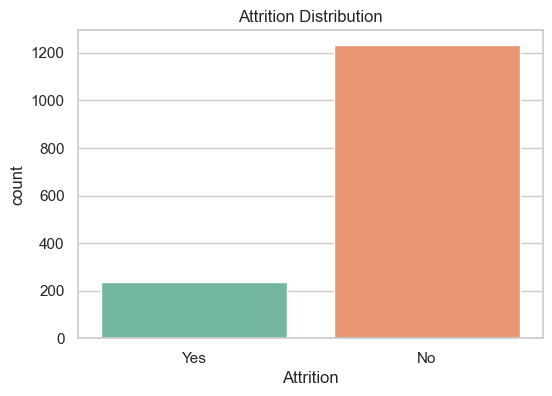

In [ ]:
# How balanced is our target?
attrition_counts = df['Attrition'].value_counts()
print(attrition_counts)
print(f"\nAttrition Rate: {attrition_counts['Yes'] / len(df) * 100:.1f}%")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition', palette='Set2')
plt.title('Attrition Distribution')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../data/hr_processed.csv')

# Separate features (X) from target (y)
# X = everything the model uses to learn
# y = what the model is trying to predict
X = df.drop(columns=['Attrition'])
y = df['Attrition']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

In [ ]:
# Split data: 80% for training, 20% for testing
# random_state=42 means we get the same split every time we run it
# stratify=y ensures both splits have the same attrition ratio

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTraining attrition rate:", f"{y_train.mean()*100:.1f}%")
print("Testing attrition rate:", f"{y_test.mean()*100:.1f}%")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../data/hr_processed.csv')

# Separate features (X) from target (y)
# X = everything the model uses to learn
# y = what the model is trying to predict
X = df.drop(columns=['Attrition'])
y = df['Attrition']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

In [ ]:
# Split data: 80% for training, 20% for testing
# random_state=42 means we get the same split every time we run it
# stratify=y ensures both splits have the same attrition ratio

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTraining attrition rate:", f"{y_train.mean()*100:.1f}%")
print("Testing attrition rate:", f"{y_test.mean()*100:.1f}%")

In [ ]:
# Scaling brings all numbers to the same range
# Why? A column with values 0-20000 (salary) would dominate 
# a column with values 1-4 (satisfaction) without scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# fit_transform on train: learns the scale FROM training data
# transform on test: applies SAME scale (never learns from test data)

print("✅ Scaling done!")
print("Sample scaled values:", X_train_scaled[0][:5])

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# scale_pos_weight handles class imbalance
# It tells the model to pay more attention to the minority class (leavers)
# Formula: number of negatives / number of positives
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

model = XGBClassifier(
    n_estimators=200,        # number of trees to build
    max_depth=4,             # how deep each tree goes
    learning_rate=0.05,      # how fast the model learns (slower = more careful)
    scale_pos_weight=scale_pos_weight,  # handles imbalance
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_scaled, y_train)
print("✅ Model trained!")

In [ ]:
# Make predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Classification report
print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Stay', 'Leave']))

# AUC-ROC Score
auc = roc_auc_score(y_test, y_prob)
print(f"\nAUC-ROC Score: {auc:.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Leave'],
            yticklabels=['Stay', 'Leave'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
# See which features the model found most useful
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../data/hr_processed.csv')

X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("✅ Data loaded and split!")
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

✅ Data loaded and split!
Train size: (1176, 52) | Test size: (294, 52)


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✅ Scaling done!")

✅ Scaling done!


In [3]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    tree_method='hist',
    device='cpu'
)

model.fit(X_train_scaled, y_train)
print("✅ Model trained!")

✅ Model trained!


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Stay       0.88      0.87      0.88       247
       Leave       0.37      0.40      0.38        47

    accuracy                           0.79       294
   macro avg       0.62      0.64      0.63       294
weighted avg       0.80      0.79      0.80       294

AUC-ROC Score: 0.7597


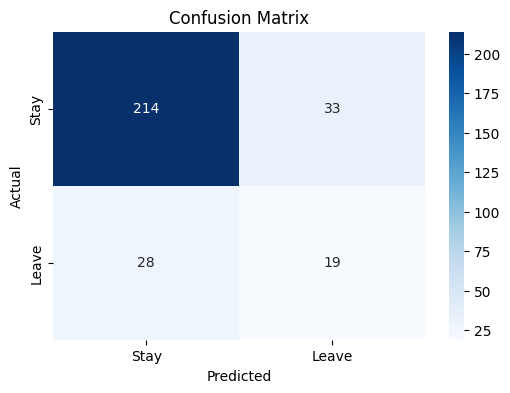

In [4]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Stay', 'Leave']))

auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC Score: {auc:.4f}")

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Leave'],
            yticklabels=['Stay', 'Leave'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_8732\348697022.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')


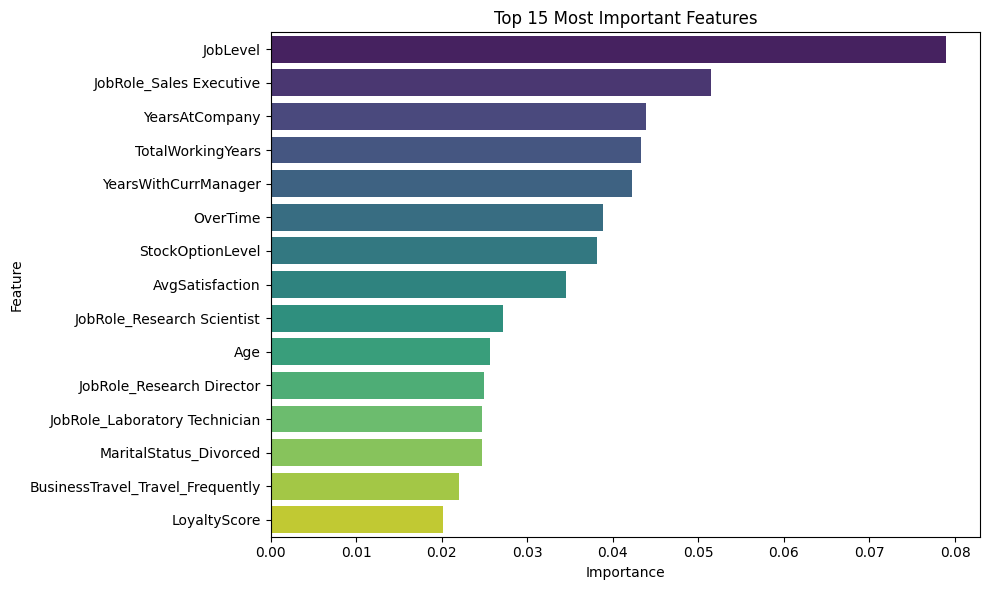

In [5]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid to search
# We're testing different combinations to find the best settings
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'min_child_weight': [1, 3]
}

base_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    tree_method='hist',
    device='cpu'
)

# cv=5 means 5-fold cross validation
# scoring='recall' because we care most about catching leavers
grid_search = GridSearchCV(
    base_model,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,          # use all CPU cores
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)
print("\n✅ Best parameters:", grid_search.best_params_)
print("✅ Best recall score:", f"{grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 100}
✅ Best recall score: 0.5947


In [8]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score

best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test_scaled)
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]

print("=" * 50)
print("OPTIMIZED MODEL RESULTS")
print("=" * 50)
print(classification_report(y_test, y_pred_best, target_names=['Stay', 'Leave']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob_best):.4f}")

# Compare before and after
print("\n--- IMPROVEMENT SUMMARY ---")
print(f"Recall (Leave) before: 0.40")
print(f"Recall (Leave) after:  {recall_score(y_test, y_pred_best):.2f}")

best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test_scaled)
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]

print("=" * 50)
print("OPTIMIZED MODEL RESULTS")
print("=" * 50)
print(classification_report(y_test, y_pred_best, target_names=['Stay', 'Leave']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob_best):.4f}")

# Compare before and after
print("\n--- IMPROVEMENT SUMMARY ---")
print(f"Recall (Leave) before: 0.40")
print(f"Recall (Leave) after:  {recall_score(y_test, y_pred_best):.2f}")

OPTIMIZED MODEL RESULTS
              precision    recall  f1-score   support

        Stay       0.90      0.85      0.88       247
       Leave       0.39      0.51      0.44        47

    accuracy                           0.80       294
   macro avg       0.65      0.68      0.66       294
weighted avg       0.82      0.80      0.81       294

AUC-ROC Score: 0.7769

--- IMPROVEMENT SUMMARY ---
Recall (Leave) before: 0.40
Recall (Leave) after:  0.51
OPTIMIZED MODEL RESULTS
              precision    recall  f1-score   support

        Stay       0.90      0.85      0.88       247
       Leave       0.39      0.51      0.44        47

    accuracy                           0.80       294
   macro avg       0.65      0.68      0.66       294
weighted avg       0.82      0.80      0.81       294

AUC-ROC Score: 0.7769

--- IMPROVEMENT SUMMARY ---
Recall (Leave) before: 0.40
Recall (Leave) after:  0.51


In [9]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the trained model
joblib.dump(best_model, '../models/hr_attrition_model.pkl')

# Save the scaler too — we need it to scale new data the same way
joblib.dump(scaler, '../models/scaler.pkl')

# Save feature names — needed for the Streamlit app
feature_names = X.columns.tolist()
joblib.dump(feature_names, '../models/feature_names.pkl')

print("✅ Model saved to models/hr_attrition_model.pkl")
print("✅ Scaler saved to models/scaler.pkl")
print("✅ Feature names saved to models/feature_names.pkl")

✅ Model saved to models/hr_attrition_model.pkl
✅ Scaler saved to models/scaler.pkl
✅ Feature names saved to models/feature_names.pkl


In [10]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# ── Load saved model, scaler and feature names ──────────────────
model = joblib.load('models/hr_attrition_model.pkl')
scaler = joblib.load('models/scaler.pkl')
feature_names = joblib.load('models/feature_names.pkl')

# ── Page config ─────────────────────────────────────────────────
st.set_page_config(
    page_title="HR Attrition Predictor",
    page_icon="👥",
    layout="wide"
)

st.title("👥 HR Employee Attrition Predictor")
st.markdown("Fill in the employee details below to predict whether they are at risk of leaving.")
st.divider()

# ── Input Form ───────────────────────────────────────────────────
col1, col2, col3 = st.columns(3)

with col1:
    st.subheader("👤 Personal Info")
    age = st.slider("Age", 18, 60, 30)
    gender = st.selectbox("Gender", ["Male", "Female"])
    marital_status = st.selectbox("Marital Status", ["Single", "Married", "Divorced"])
    distance_from_home = st.slider("Distance From Home (km)", 1, 29, 5)
    education = st.selectbox("Education Level", [1, 2, 3, 4, 5],
                             format_func=lambda x: {1:"Below College", 2:"College",
                                                     3:"Bachelor", 4:"Master", 5:"Doctor"}[x])

with col2:
    st.subheader("💼 Job Info")
    department = st.selectbox("Department", ["Sales", "Research & Development", "Human Resources"])
    job_role = st.selectbox("Job Role", [
        "Sales Executive", "Research Scientist", "Laboratory Technician",
        "Manufacturing Director", "Healthcare Representative", "Manager",
        "Sales Representative", "Research Director", "Human Resources"
    ])
    job_level = st.slider("Job Level", 1, 5, 2)
    job_involvement = st.slider("Job Involvement", 1, 4, 3)
    job_satisfaction = st.slider("Job Satisfaction", 1, 4, 3)
    overtime = st.selectbox("OverTime", ["Yes", "No"])
    business_travel = st.selectbox("Business Travel", ["Non-Travel", "Travel_Rarely", "Travel_Frequently"])

with col3:
    st.subheader("💰 Compensation & Experience")
    monthly_income = st.number_input("Monthly Income ($)", 1000, 20000, 5000)
    daily_rate = st.number_input("Daily Rate", 100, 1500, 800)
    hourly_rate = st.number_input("Hourly Rate", 30, 100, 65)
    monthly_rate = st.number_input("Monthly Rate", 2000, 27000, 14000)
    percent_salary_hike = st.slider("Percent Salary Hike", 11, 25, 15)
    stock_option_level = st.slider("Stock Option Level", 0, 3, 1)
    total_working_years = st.slider("Total Working Years", 0, 40, 10)
    years_at_company = st.slider("Years At Company", 0, 40, 5)
    years_in_current_role = st.slider("Years In Current Role", 0, 18, 3)
    years_since_last_promotion = st.slider("Years Since Last Promotion", 0, 15, 1)
    years_with_curr_manager = st.slider("Years With Current Manager", 0, 17, 3)

st.divider()

# ── More inputs ──────────────────────────────────────────────────
col4, col5 = st.columns(2)

with col4:
    st.subheader("🎓 Education & Training")
    education_field = st.selectbox("Education Field", [
        "Life Sciences", "Medical", "Marketing",
        "Technical Degree", "Human Resources", "Other"
    ])
    num_companies_worked = st.slider("Num Companies Worked", 0, 9, 2)
    training_times_last_year = st.slider("Training Times Last Year", 0, 6, 3)
    performance_rating = st.selectbox("Performance Rating", [3, 4],
                                       format_func=lambda x: {3:"Excellent", 4:"Outstanding"}[x])

with col5:
    st.subheader("😊 Satisfaction & Balance")
    environment_satisfaction = st.slider("Environment Satisfaction", 1, 4, 3)
    relationship_satisfaction = st.slider("Relationship Satisfaction", 1, 4, 3)
    work_life_balance = st.slider("Work Life Balance", 1, 4, 3)

st.divider()

# ── Predict Button ───────────────────────────────────────────────
if st.button("🔍 Predict Attrition Risk", use_container_width=True):

    # Build input dict with all raw features
    input_dict = {
        'Age': age,
        'DailyRate': daily_rate,
        'DistanceFromHome': distance_from_home,
        'Education': education,
        'EnvironmentSatisfaction': environment_satisfaction,
        'Gender': 1 if gender == "Male" else 0,
        'HourlyRate': hourly_rate,
        'JobInvolvement': job_involvement,
        'JobLevel': job_level,
        'JobSatisfaction': job_satisfaction,
        'MonthlyIncome': monthly_income,
        'MonthlyRate': monthly_rate,
        'NumCompaniesWorked': num_companies_worked,
        'OverTime': 1 if overtime == "Yes" else 0,
        'PercentSalaryHike': percent_salary_hike,
        'PerformanceRating': performance_rating,
        'RelationshipSatisfaction': relationship_satisfaction,
        'StockOptionLevel': stock_option_level,
        'TotalWorkingYears': total_working_years,
        'TrainingTimesLastYear': training_times_last_year,
        'WorkLifeBalance': work_life_balance,
        'YearsAtCompany': years_at_company,
        'YearsInCurrentRole': years_in_current_role,
        'YearsSinceLastPromotion': years_since_last_promotion,
        'YearsWithCurrManager': years_with_curr_manager,

        # Business Travel
        'BusinessTravel_Non-Travel': 1 if business_travel == "Non-Travel" else 0,
        'BusinessTravel_Travel_Frequently': 1 if business_travel == "Travel_Frequently" else 0,
        'BusinessTravel_Travel_Rarely': 1 if business_travel == "Travel_Rarely" else 0,

        # Department
        'Department_Human Resources': 1 if department == "Human Resources" else 0,
        'Department_Research & Development': 1 if department == "Research & Development" else 0,
        'Department_Sales': 1 if department == "Sales" else 0,

        # Education Field
        'EducationField_Human Resources': 1 if education_field == "Human Resources" else 0,
        'EducationField_Life Sciences': 1 if education_field == "Life Sciences" else 0,
        'EducationField_Marketing': 1 if education_field == "Marketing" else 0,
        'EducationField_Medical': 1 if education_field == "Medical" else 0,
        'EducationField_Other': 1 if education_field == "Other" else 0,
        'EducationField_Technical Degree': 1 if education_field == "Technical Degree" else 0,

        # Job Role
        'JobRole_Healthcare Representative': 1 if job_role == "Healthcare Representative" else 0,
        'JobRole_Human Resources': 1 if job_role == "Human Resources" else 0,
        'JobRole_Laboratory Technician': 1 if job_role == "Laboratory Technician" else 0,
        'JobRole_Manager': 1 if job_role == "Manager" else 0,
        'JobRole_Manufacturing Director': 1 if job_role == "Manufacturing Director" else 0,
        'JobRole_Research Director': 1 if job_role == "Research Director" else 0,
        'JobRole_Research Scientist': 1 if job_role == "Research Scientist" else 0,
        'JobRole_Sales Executive': 1 if job_role == "Sales Executive" else 0,
        'JobRole_Sales Representative': 1 if job_role == "Sales Representative" else 0,

        # Marital Status
        'MaritalStatus_Divorced': 1 if marital_status == "Divorced" else 0,
        'MaritalStatus_Married': 1 if marital_status == "Married" else 0,
        'MaritalStatus_Single': 1 if marital_status == "Single" else 0,

        # Engineered features
        'IncomePerYear': monthly_income / (total_working_years + 1),
        'LoyaltyScore': years_at_company / (total_working_years + 1),
        'AvgSatisfaction': np.mean([environment_satisfaction, job_satisfaction,
                                     relationship_satisfaction, work_life_balance])
    }

    # Convert to dataframe and align with training feature order
    input_df = pd.DataFrame([input_dict])[feature_names]

    # Scale the input
    input_scaled = scaler.transform(input_df)

    # Predict
    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1]

    # ── Display Result ───────────────────────────────────────────
    st.subheader("🎯 Prediction Result")

    if prediction == 1:
        st.error(f"⚠️ HIGH RISK — This employee is likely to leave")
        st.metric("Probability of Leaving", f"{probability*100:.1f}%")
        st.markdown("**Recommended HR Actions:**")
        st.markdown("- 💬 Schedule a one-on-one retention conversation")
        st.markdown("- 💰 Review compensation and benefits")
        st.markdown("- 📈 Discuss career growth opportunities")
        st.markdown("- ⏰ Review overtime workload if applicable")
    else:
        st.success(f"✅ LOW RISK — This employee is likely to stay")
        st.metric("Probability of Leaving", f"{probability*100:.1f}%")
        st.markdown("**Keep up the good work:**")
        st.markdown("- 🌟 Continue current engagement practices")
        st.markdown("- 📊 Monitor satisfaction scores periodically")

FileNotFoundError: [Errno 2] No such file or directory: 'models/hr_attrition_model.pkl'